 ## Exploratory Neuro-Analysis & Physiological Validation

## Project Vision
This project implements an end-to-end **Brain-Computer Interface (BCI)** pipeline designed for neuro-rehabilitation. The goal is to decode motor intentions (Motor Imagery) from raw EEG signals and translate them into digital commands.

## Objective of this Notebook
Before building machine learning models, we must validate the physiological integrity of the data. This notebook focuses on:
1. **Data Engineering**: Parsing nested MATLAB structures into a standardized `MNE-Python` format.
2. **Spectral Profiling**: Identifying the **Mu (8-13 Hz)** and **Beta (15-30 Hz)** rhythms in the motor cortex.
3. **Neural Signature Extraction**: Visualizing **Event-Related Desynchronization (ERD)** to prove the presence of motor imagery patterns.

## Dataset
* **Source**: BCI Competition IV-2a.
* **Paradigm**: 4-class motor imagery (Left hand, Right hand, Feet, Tongue).
* **Subjects**: 9 healthy participants.
* **Hardware**: 22 EEG channels (10-20 system) @ 250Hz.

## Imports and configurations 

In [1]:
import mne
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os

# Set logging to warning to keep the notebook clean
mne.set_log_level('WARNING')

# Relative path configuration
DATA_PATH = os.path.join('.', 'archive')
SUBJECTS = [f'A{i:02d}T.mat' for i in range(1, 10)]

# BCI IV-2a specific constants
FS = 250  # Sampling frequency in Hz
CHANNELS = [
    'Fz', 'FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CPz', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-left', 'EOG-central', 'EOG-right'
]

print(f"Found {len(SUBJECTS)} subjects in {DATA_PATH}")

Found 9 subjects in .\archive


## MATLAB-to-MNE Parser
MATLAB files in BCI competitions usually contain a nested structure. I create a function to extract the signal and the event markers, then wrap them into an mne.io.RawArray.

In [2]:
import scipy.io as sio
data_mat = sio.loadmat(os.path.join(DATA_PATH, SUBJECTS[0]))
print(data_mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [3]:
def load_bci_subject(file_path):
    """
    Parses the 'data' structure from BCI IV-2a MATLAB files.
    Correctly handles 22 EEG channels and 3 EOG channels.
    """
    mat = sio.loadmat(file_path)
    runs = mat['data'][0]
    
    all_raws = []
    
    # Official 22 EEG channel names for BCI IV-2a
    ch_names = [
        'Fz', 'FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
        'CP3', 'CPz', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'O1', 'Oz', 'O2', 'P6' 
    ]
    # Adding the 3 EOG channels usually present in the .mat (total 25 columns)
    ch_names = ch_names + ['EOG-left', 'EOG-central', 'EOG-right']
    
    for run in runs:
        # X: [samples x channels]
        X = run['X'][0,0]
        trial_idx = run['trial'][0,0].flatten()
        y = run['y'][0,0].flatten()
        
        # Determine how many channels we actually have in the matrix X
        n_channels = X.shape[1]
        current_ch_names = ch_names[:n_channels]
        
        # Define types: first 22 are EEG, others are EOG
        ch_types = ['eeg'] * min(n_channels, 22) + ['eog'] * max(0, n_channels - 22)
        
        info = mne.create_info(ch_names=current_ch_names, sfreq=FS, ch_types=ch_types)
        
        # Scaling: MATLAB data is in microVolts, MNE needs Volts
        raw_run = mne.io.RawArray(X.T * 1e-6, info)
        
        # Mapping events
        event_desc = {1: 'left', 2: 'right', 3: 'foot', 4: 'tongue'}
        onset = trial_idx / FS
        duration = np.full_like(onset, 4.0)
        description = [event_desc[label] for label in y]
        
        annot = mne.Annotations(onset=onset, duration=duration, description=description)
        raw_run.set_annotations(annot)
        all_raws.append(raw_run)
        
    raw_subject = mne.concatenate_raws(all_raws)
    
    # SET MONTAGE - Using 'on_missing' to avoid crashes with EOG channels
    montage = mne.channels.make_standard_montage('standard_1020')
    raw_subject.set_montage(montage, on_missing='ignore')
    
    return raw_subject

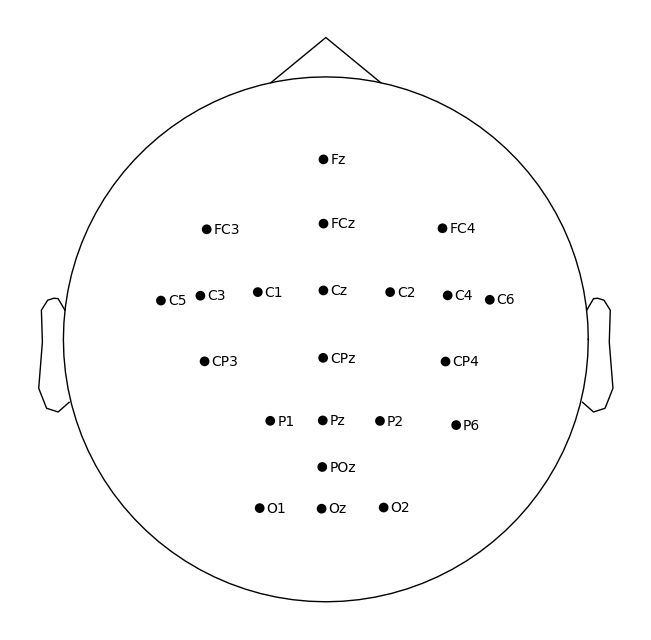

In [4]:
# Load and plot sensors
raw = load_bci_subject(os.path.join(DATA_PATH, SUBJECTS[0]))
raw.plot_sensors(show_names=True)
plt.show()

##  Mu and Beta Rhythms
Let's look at frequencies to make sure the physiological rhythms are present.


The PSD plot confirms the physiological validity of the recording. We observe a clear power peak in the alpha/mu range (~10 Hz) and a secondary prominence in the beta band (~20 Hz) over the central electrodes (C3, Cz, C4). The sharp drop-off after 30 Hz is due to our anti-aliasing and band-pass filtering, ensuring we focus on the task-relevant information.

The PSD shows the characteristic EEG 1/f decay with informative sensorimotor activity in the mu and beta bands, which are the frequency ranges most relevant for motor imagery decoding

c:\Users\ACER\anaconda3\envs\env_master_2025\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


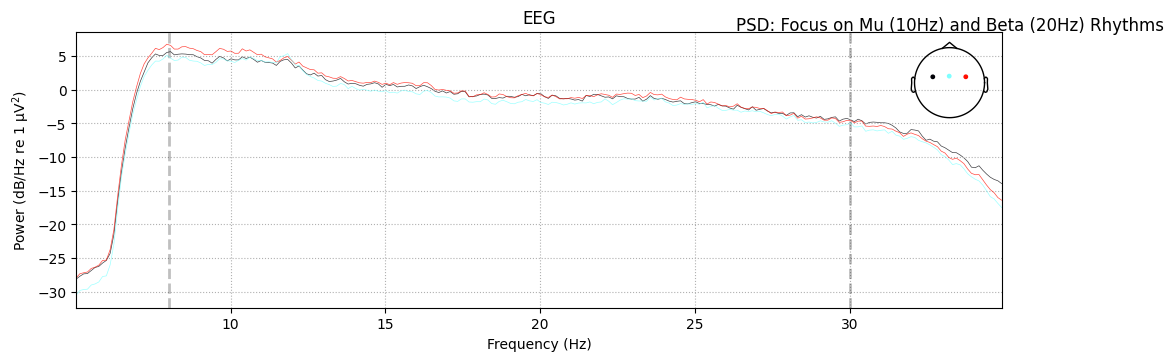

In [5]:
# 1. Band-pass filter to isolate Mu and Beta bands (8-30 Hz)
# This is where the motor imagery information lives.
raw.filter(l_freq=8., h_freq=30., fir_design='firwin')

# 2. Plot Power Spectral Density (PSD) for key motor channels
# C3 = Left Hand area, C4 = Right Hand area, Cz = Feet area
picks = ['C3', 'Cz', 'C4']
raw.compute_psd(fmin=5, fmax=35, picks=picks).plot()
plt.title("PSD: Focus on Mu (10Hz) and Beta (20Hz) Rhythms")
plt.show()

## Time-Frequency Analysis (ERD)
Morlet transform to see how the power changes over time.


This Time-Frequency Representation (TFR) highlights the Event-Related Desynchronization (ERD).

At t=0s: The visual cue appears. We notice an initial power increase (red area), likely related to visual processing and stimulus onset.

From t=1s to t=4s: A significant sustained power decrease (blue area) occurs in the 8-13 Hz and 15-25 Hz bands. This represents the 'blocking' of Mu/Beta rhythms as the motor cortex engages in imagining the movement.
This lateralized suppression is the primary feature our spatial filters (CSP) will exploit for classification.

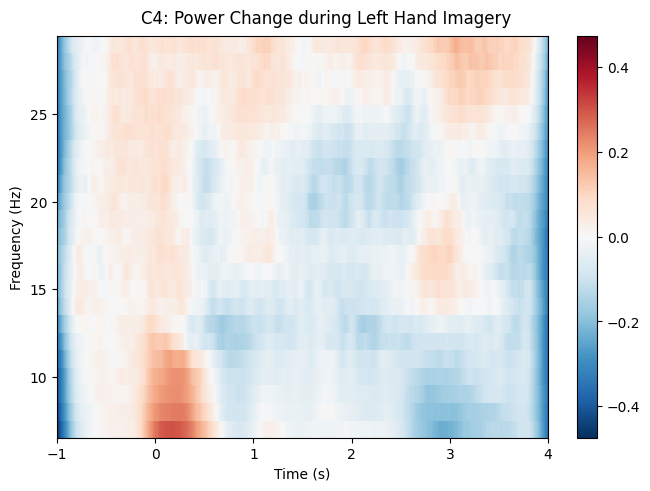

In [ ]:
from mne.time_frequency import tfr_multitaper

# 1. Define events and epochs
#  focus on 'left' vs 'right' hand imagery
event_id = {'left': 1, 'right': 2}
events, _ = mne.events_from_annotations(raw)

# Epoching: from 1 second before the cue to 4 seconds after
tmin, tmax = -1.0, 4.0
epochs = mne.Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax, 
                    baseline=(-1.0, 0), preload=True)

# 2. Calculate Time-Frequency Representation (TFR)
#  analyze frequencies from 7 to 30 Hz
freqs = np.arange(7, 30, 1) 
n_cycles = freqs / 2.  # Different cycles for different frequencies

# Analysis for Left Hand Imagery
tfr_left = tfr_multitaper(epochs['left'], freqs=freqs, n_cycles=n_cycles, 
                          return_itc=False, average=True)

# 3. Plotting the ERD effect on C4 (Ipsilateral to left hand)
# The 'logratio' mode shows the change relative to the baseline
tfr_left.plot([raw.ch_names.index('C4')], baseline=(-1.0, 0), mode='logratio', 
              title="C4: Power Change during Left Hand Imagery")
plt.show()

## Summary table portfolio

In [ ]:
print(f"{'Subject':<10} | {'Total Trials':<15} | {'Sampling Rate':<10}")
print("-" * 40)
for sub in SUBJECTS:
    try:
        path = os.path.join(DATA_PATH, sub)
        #  use a light loader for the summary
        mat = sio.loadmat(path)
        n_trials = sum([len(run['y'][0,0]) for run in mat['data'][0]])
        fs = mat['data'][0][0]['fs'][0,0][0,0]
        print(f"{sub:<10} | {n_trials:<15} | {fs:<10} Hz")
    except:
        continue

Subject    | Total Trials    | Sampling Rate
----------------------------------------
A01T.mat   | 288             | 250        Hz
A02T.mat   | 288             | 250        Hz
A03T.mat   | 288             | 250        Hz
A04T.mat   | 288             | 250        Hz
A05T.mat   | 288             | 250        Hz
A06T.mat   | 288             | 250        Hz
A07T.mat   | 288             | 250        Hz
A08T.mat   | 288             | 250        Hz
A09T.mat   | 288             | 250        Hz
